In [1]:
# Step 1: Import Libraries

# Step 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2

# For combining sparse matrices
from scipy.sparse import hstack, csr_matrix

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tanmay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tanmay\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tanmay\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


STEP 2: DATA LOADING AND EXPLORATION

Dataset Shape: (8469, 17)

First 5 rows:
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

       

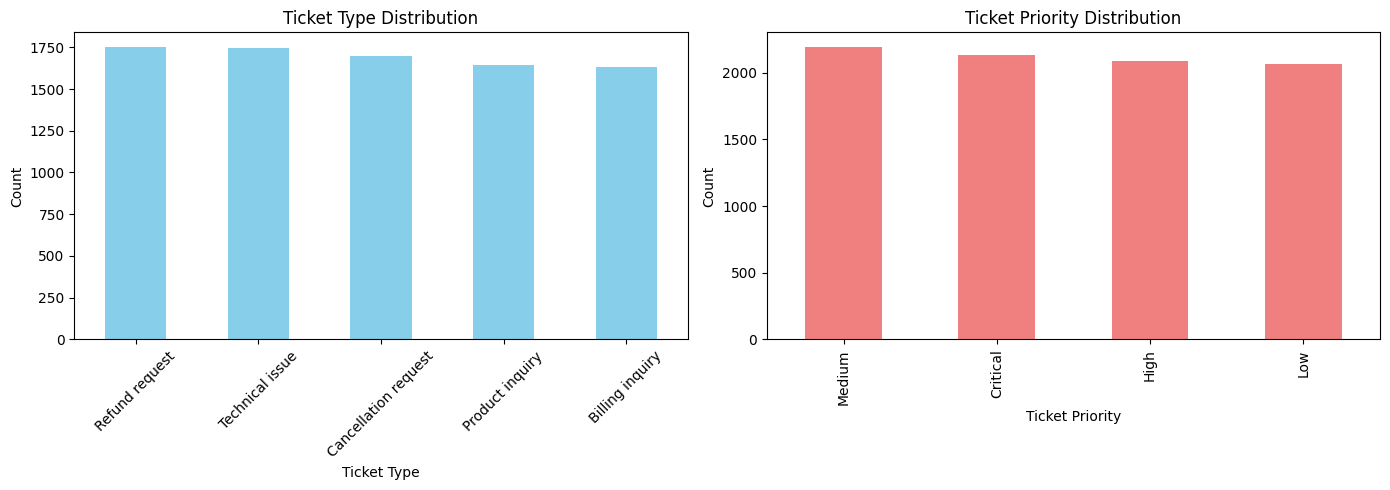

In [2]:
# Step 2: Load and Explore Data
# Step 2: Load the dataset

df = pd.read_csv('customer_support_tickets.csv')

print("="*60)
print("STEP 2: DATA LOADING AND EXPLORATION")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nTicket Type Distribution:")
print(df['Ticket Type'].value_counts())

print(f"\nTicket Priority Distribution:")
print(df['Ticket Priority'].value_counts())

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Ticket Type Distribution')
axes[0].set_xlabel('Ticket Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Ticket Priority Distribution')
axes[1].set_xlabel('Ticket Priority')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [3]:
# Step 3: Text Preprocessing

# Step 3: Text Preprocessing Function
print("\n" + "="*60)
print("STEP 3: TEXT PREPROCESSING")
print("="*60)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_advanced(text):
    """
    Advanced text cleaning function:
    - Lowercase
    - Remove placeholders like {product_purchased}
    - Remove emails, URLs, phone numbers
    - Remove special characters and digits
    - Remove stopwords and lemmatize
    """
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove placeholders like {product_purchased}
    text = re.sub(r'\{[^}]*\}', '', text)
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove phone numbers (simple pattern)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words 
             if word not in stop_words and len(word) > 2]
    
    return ' '.join(words)

# Combine Subject and Description
df['combined_text'] = (df['Ticket Subject'].fillna('') + ' ' + 
                        df['Ticket Description'].fillna(''))

# Apply cleaning
print("Cleaning text data... (this may take a moment)")
df['clean_text'] = df['combined_text'].apply(clean_text_advanced)

print(f"\nOriginal text sample:")
print(df['combined_text'].iloc[0][:200] + "...")

print(f"\nCleaned text sample:")
print(df['clean_text'].iloc[0][:200] + "...")

print(f"\nText cleaning complete!")



STEP 3: TEXT PREPROCESSING
Cleaning text data... (this may take a moment)

Original text sample:
Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your ema...

Cleaned text sample:
product setup issue please assist billing zip code appreciate requested website address please double check email address tried troubleshooting step mentioned user manual issue persists...

Text cleaning complete!


In [4]:
# Step 4: Feature Engineering

# Step 4: Feature Engineering
print("\n" + "="*60)
print("STEP 4: FEATURE ENGINEERING")
print("="*60)

def extract_key_phrases(text):
    """
    Extract key phrases that indicate ticket type or priority
    """
    text = str(text).lower()
    features = []
    
    # Billing related
    if any(word in text for word in ['bill', 'charge', 'payment', 'invoice', 'credit', 'billing']):
        features.append('billing_related')
    
    # Technical issue related
    if any(word in text for word in ['error', 'bug', 'crash', 'freeze', 'not working', 
                                      'broken', 'issue', 'problem', 'technical']):
        features.append('technical_related')
    
    # Account related
    if any(word in text for word in ['account', 'login', 'password', 'access', 'locked', 
                                      'credentials', 'sign in']):
        features.append('account_related')
    
    # Refund related
    if any(word in text for word in ['refund', 'money back', 'return', 'cancel', 'cancellation']):
        features.append('refund_related')
    
    # Product related
    if any(word in text for word in ['product', 'purchased', 'item', 'device']):
        features.append('product_related')
    
    # Urgency related
    if any(word in text for word in ['urgent', 'asap', 'immediately', 'critical', 
                                      'emergency', 'as soon as possible']):
        features.append('urgent')
    
    # Data loss related
    if any(word in text for word in ['lost', 'data loss', 'disappeared', 'deleted', 
                                      'missing', 'recover']):
        features.append('data_loss_related')
    
    # Hardware related
    if any(word in text for word in ['hardware', 'device', 'screen', 'battery', 
                                      'charger', 'noise', 'flickering']):
        features.append('hardware_related')
    
    # Software related
    if any(word in text for word in ['software', 'update', 'version', 'firmware', 
                                      'app', 'application', 'crash']):
        features.append('software_related')
    
    return ','.join(features) if features else 'none'

# Extract key phrases
print("Extracting key phrases...")
df['key_phrases'] = df['clean_text'].apply(extract_key_phrases)

print(f"\nKey phrases distribution:")
print(df['key_phrases'].value_counts().head(10))

# Create additional numerical features
print("\nCreating additional features...")
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))
df['subject_length'] = df['Ticket Subject'].fillna('').apply(lambda x: len(str(x).split()))
df['has_question_mark'] = df['combined_text'].apply(lambda x: 1 if '?' in str(x) else 0)
df['has_exclamation'] = df['combined_text'].apply(lambda x: 1 if '!' in str(x) else 0)
df['capital_ratio'] = df['combined_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)

print(f"\nFeature engineering complete!")
print(f"New features: text_length, subject_length, has_question_mark, has_exclamation, capital_ratio")



STEP 4: FEATURE ENGINEERING
Extracting key phrases...

Key phrases distribution:
key_phrases
technical_related,product_related                                      877
technical_related,product_related,hardware_related                     815
technical_related,product_related,hardware_related,software_related    563
technical_related,product_related,software_related                     556
technical_related,software_related                                     475
technical_related                                                      428
technical_related,hardware_related                                     421
technical_related,hardware_related,software_related                    235
technical_related,refund_related,product_related                       212
technical_related,refund_related                                       199
Name: count, dtype: int64

Creating additional features...

Feature engineering complete!
New features: text_length, subject_length, has_question_mark, has_

In [5]:
# Step 5: Prepare Features and Target Variables

# Step 5: Prepare Features and Target Variables
print("\n" + "="*60)
print("STEP 5: PREPARING FEATURES AND TARGETS")
print("="*60)

# Encode target variables
le_type = LabelEncoder()
le_priority = LabelEncoder()

y_type = le_type.fit_transform(df['Ticket Type'])
y_priority = le_priority.fit_transform(df['Ticket Priority'])

print(f"Ticket Type classes: {list(le_type.classes_)}")
print(f"Ticket Priority classes: {list(le_priority.classes_)}")

# 5.1: Text features using TF-IDF
print("\n5.1: Creating TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 3),  # Include unigrams, bigrams, and trigrams
    min_df=3,             # Ignore terms that appear in less than 3 documents
    max_df=0.8,           # Ignore terms that appear in more than 80% of documents
    sublinear_tf=True,    # Use 1+log(tf)
    stop_words='english'  # Use built-in stopwords
)

X_text = tfidf.fit_transform(df['clean_text'])
print(f"Text features shape: {X_text.shape}")

# 5.2: Key phrases features
print("\n5.2: Creating key phrases features...")
key_phrases_dummies = pd.get_dummies(df['key_phrases'], prefix='phrase')
X_phrases = csr_matrix(key_phrases_dummies.values)
print(f"Key phrases features shape: {X_phrases.shape}")

# 5.3: Categorical metadata features
print("\n5.3: Creating metadata features...")
metadata_cols = ['Product Purchased', 'Ticket Channel', 'Customer Gender']

# Fill missing values
for col in metadata_cols:
    df[col] = df[col].fillna('Unknown')

# One-hot encode
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_meta = encoder.fit_transform(df[metadata_cols])
print(f"Metadata features shape: {X_meta.shape}")
print(f"Metadata feature names: {encoder.get_feature_names_out(metadata_cols).tolist()[:10]}...")

# 5.4: Numerical features
print("\n5.4: Creating numerical features...")
numerical_cols = ['text_length', 'subject_length', 'has_question_mark', 'has_exclamation', 'capital_ratio']
X_numerical = csr_matrix(df[numerical_cols].values)
print(f"Numerical features shape: {X_numerical.shape}")

# 5.5: Combine all features
print("\n5.5: Combining all features...")
X_combined = hstack([X_text, X_phrases, X_meta, X_numerical])
print(f"Combined features shape: {X_combined.shape}")

# 5.6: Train-test split
print("\n5.6: Splitting data into train and test sets...")
X_train, X_test, y_type_train, y_type_test, y_priority_train, y_priority_test = train_test_split(
    X_combined, y_type, y_priority, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_type  # Stratify based on ticket type
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")



STEP 5: PREPARING FEATURES AND TARGETS
Ticket Type classes: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']
Ticket Priority classes: ['Critical', 'High', 'Low', 'Medium']

5.1: Creating TF-IDF features...
Text features shape: (8469, 3000)

5.2: Creating key phrases features...
Key phrases features shape: (8469, 184)

5.3: Creating metadata features...
Metadata features shape: (8469, 49)
Metadata feature names: ['Product Purchased_Adobe Photoshop', 'Product Purchased_Amazon Echo', 'Product Purchased_Amazon Kindle', 'Product Purchased_Apple AirPods', 'Product Purchased_Asus ROG', 'Product Purchased_Autodesk AutoCAD', 'Product Purchased_Bose QuietComfort', 'Product Purchased_Bose SoundLink Speaker', 'Product Purchased_Canon DSLR Camera', 'Product Purchased_Canon EOS']...

5.4: Creating numerical features...
Numerical features shape: (8469, 5)

5.5: Combining all features...
Combined features shape: (8469, 3238)

5.6: Splitting data into


STEP 6: TICKET TYPE CLASSIFICATION

6.1: Training Logistic Regression...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'C': 10}
Weighted F1 Score: 0.2061

6.2: Training Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Weighted F1 Score: 0.1995

6.3: Training Linear SVC...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'C': 10}
Weighted F1 Score: 0.2142

6.4: Training Multinomial Naive Bayes...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'alpha': 1.0}
Weighted F1 Score: 0.1964

6.5: Model Comparison for Ticket Type
----------------------------------------
Linear SVC          : 0.2142
Logistic Regression : 0.2061
Random Forest       : 0.1995
Naive Bayes         : 0.1964

Best model: Linear SVC

Detailed Classification Report:
                      precision    recall  f1-score   sup

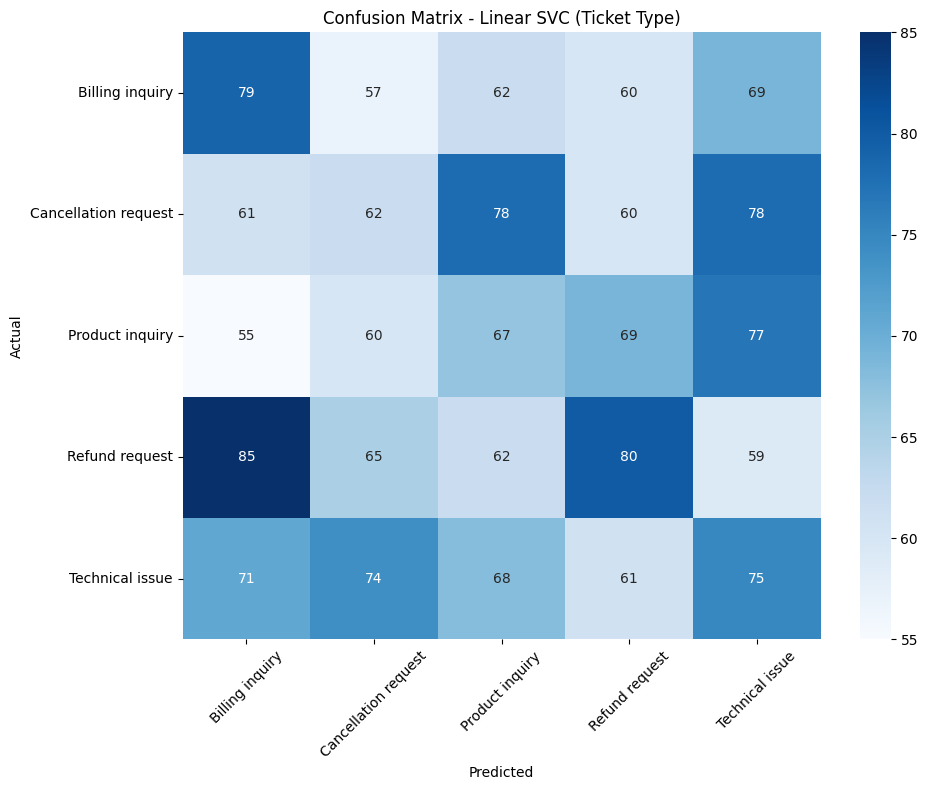

In [6]:
# Step 6: Ticket Type Classification

# Step 6: Ticket Type Classification
print("\n" + "="*60)
print("STEP 6: TICKET TYPE CLASSIFICATION")
print("="*60)

# Dictionary to store results
type_results = {}

# 6.1: Logistic Regression
print("\n6.1: Training Logistic Regression...")
lr_type = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(lr_type, param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_type_train)

y_pred_lr = grid_lr.predict(X_test)
f1_lr = f1_score(y_type_test, y_pred_lr, average='weighted')
type_results['Logistic Regression'] = f1_lr

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Weighted F1 Score: {f1_lr:.4f}")

# 6.2: Random Forest
print("\n6.2: Training Random Forest...")
rf_type = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_type, param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_type_train)

y_pred_rf = grid_rf.predict(X_test)
f1_rf = f1_score(y_type_test, y_pred_rf, average='weighted')
type_results['Random Forest'] = f1_rf

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Weighted F1 Score: {f1_rf:.4f}")

# 6.3: Linear SVC
print("\n6.3: Training Linear SVC...")
svc_type = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
param_grid_svc = {'C': [0.01, 0.1, 1, 10]}

grid_svc = GridSearchCV(svc_type, param_grid_svc, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_svc.fit(X_train, y_type_train)

y_pred_svc = grid_svc.predict(X_test)
f1_svc = f1_score(y_type_test, y_pred_svc, average='weighted')
type_results['Linear SVC'] = f1_svc

print(f"Best parameters: {grid_svc.best_params_}")
print(f"Weighted F1 Score: {f1_svc:.4f}")

# 6.4: Multinomial Naive Bayes
print("\n6.4: Training Multinomial Naive Bayes...")
nb_type = MultinomialNB()
param_grid_nb = {'alpha': [0.01, 0.1, 0.5, 1.0]}

grid_nb = GridSearchCV(nb_type, param_grid_nb, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_nb.fit(X_train, y_type_train)

y_pred_nb = grid_nb.predict(X_test)
f1_nb = f1_score(y_type_test, y_pred_nb, average='weighted')
type_results['Naive Bayes'] = f1_nb

print(f"Best parameters: {grid_nb.best_params_}")
print(f"Weighted F1 Score: {f1_nb:.4f}")

# 6.5: Compare results
print("\n6.5: Model Comparison for Ticket Type")
print("-" * 40)
for model, score in sorted(type_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:20s}: {score:.4f}")

# Select best model
best_type_model_name = max(type_results, key=type_results.get)
best_type_model = {
    'Logistic Regression': grid_lr,
    'Random Forest': grid_rf,
    'Linear SVC': grid_svc,
    'Naive Bayes': grid_nb
}[best_type_model_name]

print(f"\nBest model: {best_type_model_name}")
print("\nDetailed Classification Report:")
y_pred_best_type = best_type_model.predict(X_test)
print(classification_report(y_type_test, y_pred_best_type, 
                          target_names=le_type.classes_))

# Confusion Matrix for best model
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_type_test, y_pred_best_type)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_type.classes_, 
            yticklabels=le_type.classes_)
plt.title(f'Confusion Matrix - {best_type_model_name} (Ticket Type)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


STEP 7: TICKET PRIORITY CLASSIFICATION

7.1: Training Logistic Regression for Priority...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'C': 0.01}
Weighted F1 Score: 0.2534

7.2: Training Random Forest for Priority...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Weighted F1 Score: 0.2585

7.3: Training Linear SVC for Priority...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'C': 0.01}
Weighted F1 Score: 0.2548

7.4: Model Comparison for Ticket Priority
----------------------------------------
Random Forest       : 0.2585
Linear SVC          : 0.2548
Logistic Regression : 0.2534

Best model: Random Forest

Detailed Classification Report:
              precision    recall  f1-score   support

    Critical       0.26      0.27      0.26       441
        High       0.28      0.25      0.27       424
         Low       0.24      

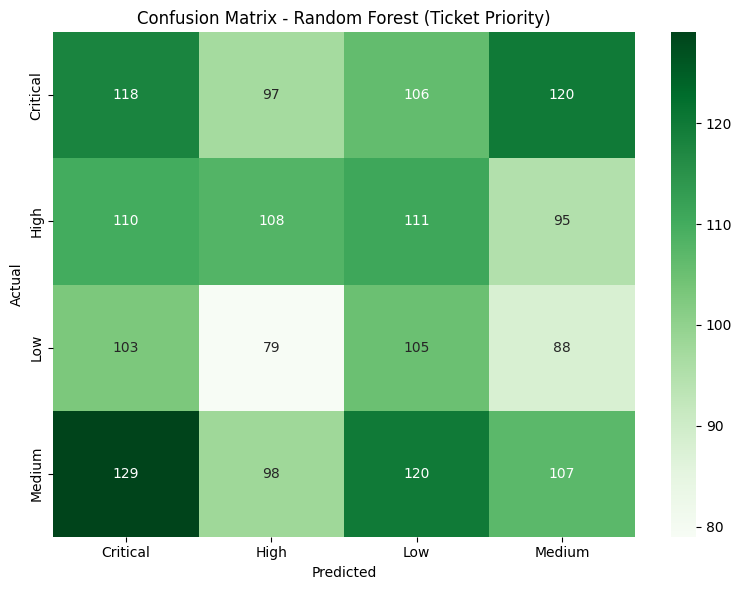

In [7]:
# Step 7: Ticket Priority Classification

# Step 7: Ticket Priority Classification
print("\n" + "="*60)
print("STEP 7: TICKET PRIORITY CLASSIFICATION")
print("="*60)

# Dictionary to store results
priority_results = {}

# 7.1: Logistic Regression
print("\n7.1: Training Logistic Regression for Priority...")
lr_priority = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

grid_lr_p = GridSearchCV(lr_priority, param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_lr_p.fit(X_train, y_priority_train)

y_pred_lr_p = grid_lr_p.predict(X_test)
f1_lr_p = f1_score(y_priority_test, y_pred_lr_p, average='weighted')
priority_results['Logistic Regression'] = f1_lr_p

print(f"Best parameters: {grid_lr_p.best_params_}")
print(f"Weighted F1 Score: {f1_lr_p:.4f}")

# 7.2: Random Forest
print("\n7.2: Training Random Forest for Priority...")
rf_priority = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf_p = GridSearchCV(rf_priority, param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf_p.fit(X_train, y_priority_train)

y_pred_rf_p = grid_rf_p.predict(X_test)
f1_rf_p = f1_score(y_priority_test, y_pred_rf_p, average='weighted')
priority_results['Random Forest'] = f1_rf_p

print(f"Best parameters: {grid_rf_p.best_params_}")
print(f"Weighted F1 Score: {f1_rf_p:.4f}")

# 7.3: Linear SVC
print("\n7.3: Training Linear SVC for Priority...")
svc_priority = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
param_grid_svc = {'C': [0.01, 0.1, 1, 10]}

grid_svc_p = GridSearchCV(svc_priority, param_grid_svc, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_svc_p.fit(X_train, y_priority_train)

y_pred_svc_p = grid_svc_p.predict(X_test)
f1_svc_p = f1_score(y_priority_test, y_pred_svc_p, average='weighted')
priority_results['Linear SVC'] = f1_svc_p

print(f"Best parameters: {grid_svc_p.best_params_}")
print(f"Weighted F1 Score: {f1_svc_p:.4f}")

# 7.4: Compare results
print("\n7.4: Model Comparison for Ticket Priority")
print("-" * 40)
for model, score in sorted(priority_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:20s}: {score:.4f}")

# Select best model
best_priority_model_name = max(priority_results, key=priority_results.get)
best_priority_model = {
    'Logistic Regression': grid_lr_p,
    'Random Forest': grid_rf_p,
    'Linear SVC': grid_svc_p
}[best_priority_model_name]

print(f"\nBest model: {best_priority_model_name}")
print("\nDetailed Classification Report:")
y_pred_best_priority = best_priority_model.predict(X_test)
print(classification_report(y_priority_test, y_pred_best_priority, 
                          target_names=le_priority.classes_))

# Confusion Matrix for best model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_priority_test, y_pred_best_priority)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_priority.classes_,
            yticklabels=le_priority.classes_)
plt.title(f'Confusion Matrix - {best_priority_model_name} (Ticket Priority)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [8]:
# Step 8: Feature Importance Analysis

# Step 8: Feature Importance Analysis
print("\n" + "="*60)
print("STEP 8: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get all feature names
feature_names = []
feature_names.extend(tfidf.get_feature_names_out().tolist())
feature_names.extend(key_phrases_dummies.columns.tolist())
feature_names.extend(encoder.get_feature_names_out(metadata_cols).tolist())
feature_names.extend(numerical_cols)

print(f"Total features: {len(feature_names)}")

# 8.1: Analyze best type classifier
print("\n8.1: Top features for Ticket Type classification")
print("-" * 40)

if hasattr(best_type_model.best_estimator_, 'coef_'):
    # For linear models
    coefficients = best_type_model.best_estimator_.coef_
    
    for i, class_name in enumerate(le_type.classes_):
        print(f"\nTop 10 features for {class_name}:")
        top_indices = np.argsort(coefficients[i])[-10:][::-1]
        for idx in top_indices[:5]:  # Show top 5
            if coefficients[i][idx] > 0:
                print(f"  {feature_names[idx]}: {coefficients[i][idx]:.4f}")
                
elif hasattr(best_type_model.best_estimator_, 'feature_importances_'):
    # For tree-based models
    importances = best_type_model.best_estimator_.feature_importances_
    top_indices = np.argsort(importances)[-20:][::-1]
    
    print("\nTop 20 most important features overall:")
    for i, idx in enumerate(top_indices[:10]):  # Show top 10
        print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# 8.2: Analyze best priority classifier
print("\n8.2: Top features for Ticket Priority classification")
print("-" * 40)

if hasattr(best_priority_model.best_estimator_, 'coef_'):
    # For linear models
    coefficients = best_priority_model.best_estimator_.coef_
    
    for i, class_name in enumerate(le_priority.classes_):
        print(f"\nTop 10 features for {class_name}:")
        top_indices = np.argsort(coefficients[i])[-10:][::-1]
        for idx in top_indices[:5]:  # Show top 5
            if coefficients[i][idx] > 0:
                print(f"  {feature_names[idx]}: {coefficients[i][idx]:.4f}")
                
elif hasattr(best_priority_model.best_estimator_, 'feature_importances_'):
    # For tree-based models
    importances = best_priority_model.best_estimator_.feature_importances_
    top_indices = np.argsort(importances)[-20:][::-1]
    
    print("\nTop 20 most important features overall:")
    for i, idx in enumerate(top_indices[:10]):  # Show top 10
        print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")
        



STEP 8: FEATURE IMPORTANCE ANALYSIS
Total features: 3238

8.1: Top features for Ticket Type classification
----------------------------------------

Top 10 features for Billing inquiry:
  configuration: 4.6944
  enter email: 4.4747
  connect: 4.4026
  following link: 4.3177
  decided: 4.3168

Top 10 features for Cancellation request:
  connection: 5.5721
  account noticed peculiar: 4.9192
  admin: 4.6999
  include product: 4.2885
  stock contact: 4.1879

Top 10 features for Product inquiry:
  assist going: 5.1411
  past: 5.0941
  using different: 4.9056
  accidentally: 4.4738
  configured: 4.4071

Top 10 features for Refund request:
  unlock: 4.8907
  way recover: 4.8351
  working fine: 4.7834
  contact vendor: 4.4973
  item list: 4.3775

Top 10 features for Technical issue:
  launch: 5.6576
  provider: 5.3517
  troubleshooting: 4.8063
  occurred: 4.6924
  history: 4.6626

8.2: Top features for Ticket Priority classification
----------------------------------------

Top 20 most import

In [9]:
# Step 9: Cross-Validation and Final Evaluation

# Step 9: Cross-Validation and Final Evaluation
print("\n" + "="*60)
print("STEP 9: CROSS-VALIDATION AND FINAL EVALUATION")
print("="*60)

# 9.1: Cross-validation for best type model
print("\n9.1: 5-Fold Cross-Validation for Ticket Type")
print("-" * 40)

cv_scores_type = cross_val_score(
    best_type_model.best_estimator_, 
    X_train, y_type_train, 
    cv=5, 
    scoring='f1_weighted'
)

print(f"CV Scores: {cv_scores_type}")
print(f"Mean CV Score: {cv_scores_type.mean():.4f} (+/- {cv_scores_type.std() * 2:.4f})")

# 9.2: Cross-validation for best priority model
print("\n9.2: 5-Fold Cross-Validation for Ticket Priority")
print("-" * 40)

cv_scores_priority = cross_val_score(
    best_priority_model.best_estimator_, 
    X_train, y_priority_train, 
    cv=5, 
    scoring='f1_weighted'
)

print(f"CV Scores: {cv_scores_priority}")
print(f"Mean CV Score: {cv_scores_priority.mean():.4f} (+/- {cv_scores_priority.std() * 2:.4f})")

# 9.3: Final evaluation on test set
print("\n9.3: Final Test Set Evaluation")
print("-" * 40)

# Ticket Type
y_type_final_pred = best_type_model.predict(X_test)
type_accuracy = accuracy_score(y_type_test, y_type_final_pred)
type_f1 = f1_score(y_type_test, y_type_final_pred, average='weighted')

# Ticket Priority
y_priority_final_pred = best_priority_model.predict(X_test)
priority_accuracy = accuracy_score(y_priority_test, y_priority_final_pred)
priority_f1 = f1_score(y_priority_test, y_priority_final_pred, average='weighted')

print(f"Ticket Type - Accuracy: {type_accuracy:.4f}, Weighted F1: {type_f1:.4f}")
print(f"Ticket Priority - Accuracy: {priority_accuracy:.4f}, Weighted F1: {priority_f1:.4f}")




STEP 9: CROSS-VALIDATION AND FINAL EVALUATION

9.1: 5-Fold Cross-Validation for Ticket Type
----------------------------------------
CV Scores: [0.20248766 0.19610397 0.20368619 0.19407418 0.21168143]
Mean CV Score: 0.2016 (+/- 0.0124)

9.2: 5-Fold Cross-Validation for Ticket Priority
----------------------------------------
CV Scores: [0.24310139 0.26216075 0.26257016 0.23359257 0.25840496]
Mean CV Score: 0.2520 (+/- 0.0232)

9.3: Final Test Set Evaluation
----------------------------------------
Ticket Type - Accuracy: 0.2143, Weighted F1: 0.2142
Ticket Priority - Accuracy: 0.2586, Weighted F1: 0.2585


In [14]:
# Step 10: Prediction Function for New Tickets (CORRECTED)
print("\n" + "="*60)
print("STEP 10: PREDICTION FUNCTION FOR NEW TICKETS")
print("="*60)

def predict_ticket(subject, description, product=None, channel=None, gender=None,
                  tfidf=None, key_phrases_dummies=None, encoder=None, 
                  metadata_cols=None, numerical_cols=None,
                  best_type_model=None, best_priority_model=None,
                  le_type=None, le_priority=None):
    """
    Predict ticket type and priority for a new ticket
    
    Parameters:
    - subject: Ticket subject (string)
    - description: Ticket description (string)
    - product: Product purchased (optional)
    - channel: Ticket channel (optional)
    - gender: Customer gender (optional)
    - Plus all fitted transformers and models as parameters
    
    Returns:
    - Dictionary with predictions and probabilities
    """
    
    # Check if all required objects are provided
    required_objects = {
        'tfidf': tfidf,
        'key_phrases_dummies': key_phrases_dummies,
        'encoder': encoder,
        'metadata_cols': metadata_cols,
        'numerical_cols': numerical_cols,
        'best_type_model': best_type_model,
        'best_priority_model': best_priority_model,
        'le_type': le_type,
        'le_priority': le_priority
    }
    
    missing_objects = [name for name, obj in required_objects.items() if obj is None]
    if missing_objects:
        raise ValueError(f"Missing required fitted objects: {missing_objects}")
    
    try:
        # Create a dataframe with the new ticket (SINGLE ROW)
        new_data = pd.DataFrame({
            'Ticket Subject': [subject],
            'Ticket Description': [description],
            'Product Purchased': [product if product else 'Unknown'],
            'Ticket Channel': [channel if channel else 'Unknown'],
            'Customer Gender': [gender if gender else 'Unknown']
        })
        
        # Combine subject and description for text processing
        combined_text = subject + ' ' + description
        
        # Clean text
        cleaned_text = clean_text_advanced(combined_text)
        new_data['clean_text'] = [cleaned_text]
        
        # Extract key phrases (handle multiple phrases)
        key_phrases_list = extract_key_phrases(cleaned_text)
        new_data['key_phrases'] = [key_phrases_list]  # Store as list
        
        # Create numerical features
        new_data['text_length'] = len(cleaned_text.split())
        new_data['subject_length'] = len(str(subject).split())
        new_data['has_question_mark'] = 1 if '?' in combined_text else 0
        new_data['has_exclamation'] = 1 if '!' in combined_text else 0
        
        # Capital ratio (avoid division by zero)
        text_len = len(combined_text)
        if text_len > 0:
            capital_count = sum(1 for c in combined_text if c.isupper())
            new_data['capital_ratio'] = capital_count / text_len
        else:
            new_data['capital_ratio'] = 0
        
        # Transform features
        X_text_new = tfidf.transform(new_data['clean_text'])
        
        # Key phrases - create dummy variables for ALL extracted phrases
        key_phrases_dummies_new = pd.DataFrame(0, index=[0], columns=key_phrases_dummies.columns)
        
        # Set value for each extracted key phrase
        for phrase in key_phrases_list:
            phrase_col = f"phrase_{phrase}"
            if phrase_col in key_phrases_dummies_new.columns:
                key_phrases_dummies_new.loc[0, phrase_col] = 1
        
        X_phrases_new = csr_matrix(key_phrases_dummies_new.values)
        
        # Metadata
        X_meta_new = encoder.transform(new_data[metadata_cols])
        
        # Numerical
        X_numerical_new = csr_matrix(new_data[numerical_cols].values)
        
        # Combine all features
        X_new = hstack([X_text_new, X_phrases_new, X_meta_new, X_numerical_new])
        
        # Predict
        type_pred = best_type_model.predict(X_new)[0]
        priority_pred = best_priority_model.predict(X_new)[0]
        
        # Get probabilities if available
        type_proba = None
        priority_proba = None
        
        if hasattr(best_type_model, 'predict_proba'):
            type_proba = best_type_model.predict_proba(X_new)[0]
        
        if hasattr(best_priority_model, 'predict_proba'):
            priority_proba = best_priority_model.predict_proba(X_new)[0]
        
        # Decode predictions
        type_label = le_type.inverse_transform([type_pred])[0]
        priority_label = le_priority.inverse_transform([priority_pred])[0]
        
        result = {
            'ticket_type': type_label,
            'ticket_priority': priority_label
        }
        
        # Add probabilities if available
        if type_proba is not None:
            type_probs = {}
            for i, prob in enumerate(type_proba):
                type_probs[le_type.inverse_transform([i])[0]] = prob
            # Sort by probability and get top 3
            result['type_probabilities'] = dict(sorted(type_probs.items(), 
                                                       key=lambda x: x[1], reverse=True)[:3])
        
        if priority_proba is not None:
            priority_probs = {}
            for i, prob in enumerate(priority_proba):
                priority_probs[le_priority.inverse_transform([i])[0]] = prob
            result['priority_probabilities'] = dict(sorted(priority_probs.items(), 
                                                            key=lambda x: x[1], reverse=True))
        
        return result
        
    except Exception as e:
        print(f"Error making prediction: {str(e)}")
        return {
            'ticket_type': 'Unknown',
            'ticket_priority': 'Unknown',
            'error': str(e)
        }

# Store fitted objects in a dictionary for easy passing
fitted_models = {
    'tfidf': tfidf,
    'key_phrases_dummies': key_phrases_dummies,
    'encoder': encoder,
    'metadata_cols': metadata_cols,
    'numerical_cols': numerical_cols,
    'best_type_model': best_type_model,
    'best_priority_model': best_priority_model,
    'le_type': le_type,
    'le_priority': le_priority
}

# Test the prediction function with sample tickets
print("\n" + "-" * 40)
print("TESTING PREDICTION FUNCTION")
print("-" * 40)

# Test Case 1: Technical issue with urgency
print("\nTEST CASE 1: Technical Issue")
sample_subject = "Can't log into my account"
sample_description = "I've tried multiple times but keep getting invalid credentials error. Please help urgently!"

result = predict_ticket(sample_subject, sample_description, **fitted_models)
print(f"\nSubject: {sample_subject}")
print(f"Description: {sample_description}")
print(f"\n✅ Predicted Ticket Type: {result['ticket_type']}")
print(f"✅ Predicted Ticket Priority: {result['ticket_priority']}")

if 'type_probabilities' in result:
    print("\n📊 Type Probabilities:")
    for t, p in result['type_probabilities'].items():
        print(f"  {t}: {p:.2%}")

if 'priority_probabilities' in result:
    print("\n📊 Priority Probabilities:")
    for p, prob in result['priority_probabilities'].items():
        print(f"  {p}: {prob:.2%}")

# Test Case 2: Billing inquiry
print("\n" + "-" * 40)
print("TEST CASE 2: Billing Inquiry")
sample_subject2 = "Wrong charge on my credit card"
sample_description2 = "I was charged twice for the same subscription. Please issue a refund."

result2 = predict_ticket(sample_subject2, sample_description2, **fitted_models)
print(f"\nSubject: {sample_subject2}")
print(f"Description: {sample_description2}")
print(f"\n✅ Predicted Ticket Type: {result2['ticket_type']}")
print(f"✅ Predicted Ticket Priority: {result2['ticket_priority']}")

if 'type_probabilities' in result2:
    print("\n📊 Type Probabilities:")
    for t, p in result2['type_probabilities'].items():
        print(f"  {t}: {p:.2%}")

# Test Case 3: Refund request
print("\n" + "-" * 40)
print("TEST CASE 3: Refund Request")
sample_subject3 = "Product not working, want my money back"
sample_description3 = "The laptop I bought last week keeps freezing. I want to return it for a full refund."

result3 = predict_ticket(sample_subject3, sample_description3, **fitted_models)
print(f"\nSubject: {sample_subject3}")
print(f"Description: {sample_description3}")
print(f"\n✅ Predicted Ticket Type: {result3['ticket_type']}")
print(f"✅ Predicted Ticket Priority: {result3['ticket_priority']}")

if 'type_probabilities' in result3:
    print("\n📊 Type Probabilities:")
    for t, p in result3['type_probabilities'].items():
        print(f"  {t}: {p:.2%}")


STEP 10: PREDICTION FUNCTION FOR NEW TICKETS

----------------------------------------
TESTING PREDICTION FUNCTION
----------------------------------------

TEST CASE 1: Technical Issue

Subject: Can't log into my account
Description: I've tried multiple times but keep getting invalid credentials error. Please help urgently!

✅ Predicted Ticket Type: Technical issue
✅ Predicted Ticket Priority: Low

📊 Priority Probabilities:
  Low: 32.69%
  High: 26.46%
  Medium: 22.78%
  Critical: 18.07%

----------------------------------------
TEST CASE 2: Billing Inquiry

Subject: Wrong charge on my credit card
Description: I was charged twice for the same subscription. Please issue a refund.

✅ Predicted Ticket Type: Technical issue
✅ Predicted Ticket Priority: High

----------------------------------------
TEST CASE 3: Refund Request

Subject: Product not working, want my money back
Description: The laptop I bought last week keeps freezing. I want to return it for a full refund.

✅ Predicted Tic